In [22]:
import tensorflow as tf
from tensorflow.keras import regularizers
from kan import *
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from torch import autograd
from tqdm import tqdm
import torch.optim as optim
import torch

In [23]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [24]:
def loss_Liouvill(y, y_double_dot, eigenvalues, dx):

    resid = y_double_dot + y * eigenvalues

    L_ode = torch.sum(resid ** 2) / y.shape[0]

    integral_norm = torch.sum(y ** 2 * dx, dim=0)  # форма (M,)

    L_n = torch.sum((integral_norm - 1.0) ** 2)


    L_bc = torch.sum(y[0, :] ** 2) + torch.sum(y[-1, :] ** 2)

    M = y.shape[1]                # число функций
    orth_losses = []               # список для квадратов интегралов каждой пары

    for i in range(M):
        for j in range(i + 1, M):
            # Интеграл произведения i-го и j-го столбцов
            prod_mean = torch.sum(y[:, i] * y[:, j] * dx)  # скаляр
            orth_losses.append(prod_mean ** 2)

    # Если M < 2, ортогональность не требуется – просто 0.
    L_ort = sum(orth_losses) if orth_losses else torch.tensor(0.0, device=y.device)

    return L_ode, L_bc, L_n, L_ort

In [25]:
N = 100
M = 3
# x_coll = torch.rand(N, 1, requires_grad=True, dtype=torch.float32)
x_coll = torch.linspace(0, np.pi, N, requires_grad=True, dtype=torch.float32, device=device)
x_coll = x_coll.unsqueeze(1) 

dx = (np.pi - 0) / (N - 1)
# if torch.backends.mps.is_available():
#     x_coll = x_coll.to('mps')

# Модель: 1 вход, скрытые слои, M выходов
model = KAN(width=[1, 8, M], grid=5, k=3)

checkpoint directory created: ./model
saving model version 0.0


In [26]:
if torch.backends.mps.is_available():
    model.to(torch.device("mps"))
    print("Модель загружена на GPU (MPS)")
else:
    print("MPS недоступен, используется CPU")

Модель загружена на GPU (MPS)


In [27]:

# n_collocation = 100  # количество точек коллокации
# x_coll = torch.rand(n_collocation, 1)      # x в [0,1]

# Включаем requires_grad, чтобы позже вычислять производные по x и t
# x_coll.requires_grad_(True)

In [28]:
# ----------------------------------------------------------------------
# 4. НАСТРОЙКА ОПТИМИЗАТОРА
# ----------------------------------------------------------------------
# Используем LBFGS — один из лучших оптимизаторов для задач с гладкими
#   функциями потерь, характерных для PINN. Он требует специальной
#   функции closure(), которая вычисляет loss и градиенты.
optimizer = optim.LBFGS(model.parameters(), lr=1.0, max_iter=10)
# optimizer = optim.Adam(model.parameters(), lr=0.1)
# lr=1.0 — learning rate (для LBFGS можно брать большие значения)
# max_iter — максимальное число итераций за один вызов step()

In [29]:
# eigenvalues = torch.nn.Parameter(torch.tensor([1., 4., 9.]))

In [30]:
eigenvalues = torch.tensor([1, 4, 9], dtype=torch.float32, device=device)

def closure():

    optimizer.zero_grad()

    inputs_coll = torch.cat([x_coll], dim=1)   
    u = model(inputs_coll)                         
    # print(u)

    u_xx_list = []
    for i in range(M):
        u_i = u[:, i:i+1]
        # Первая производная
        u_i_x = torch.autograd.grad(u_i, x_coll,
                                    grad_outputs=torch.ones_like(u_i),
                                    create_graph=True)[0]
        # Вторая производная
        u_i_xx = torch.autograd.grad(u_i_x, x_coll,
                                    grad_outputs=torch.ones_like(u_i_x),
                                    create_graph=True)[0]

        u_xx_list.append(u_i_xx)

    u_xx = torch.cat(u_xx_list, dim=1) # (N, M)

    L_ode, L_bc, L_norm, L_ort = loss_Liouvill(u, u_xx, eigenvalues, dx)
    
    loss = L_ode + L_bc + L_norm + L_ort
    # Обратное распространение: вычисляем градиенты loss по параметрам модели
    loss.backward()

    # Возвращаем значение loss (требуется для LBFGS)
    return loss

In [31]:
# ----------------------------------------------------------------------
# 6. ЦИКЛ ОБУЧЕНИЯ
# ----------------------------------------------------------------------
n_epochs = 50   # количество эпох (вызовов optimizer.step)
error_all = []
for epoch in range(n_epochs):
    # Выполняем один шаг оптимизатора. LBFGS внутри выполнит несколько
    #   итераций (до 20, заданных max_iter) и обновит веса.
    optimizer.step(closure)
    error_all.append(closure().item())
    # Каждые 10 эпох выводим текущее значение функции потерь
    if epoch % 10 == 0:
        # Вызываем closure для получения текущего loss (без обновления весов)
        current_loss = closure().item()
        print(f"Эпоха {epoch}, Loss = {current_loss:.2e}")
        

Эпоха 0, Loss = 2.82e+00
Эпоха 10, Loss = 6.09e-01
Эпоха 20, Loss = 2.22e-03
Эпоха 30, Loss = 8.81e-04
Эпоха 40, Loss = 6.24e-04


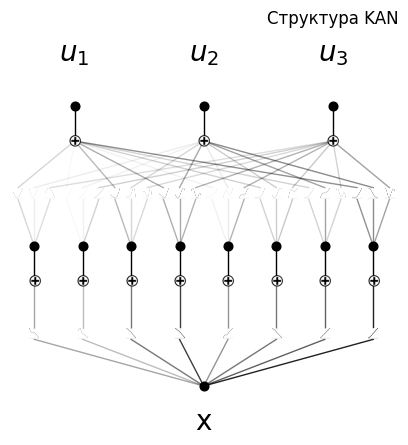

In [39]:
# После обучения (и опционально после prune) вызовите:
model.plot(in_vars=['x'], out_vars=['$u_1$', '$u_2$', '$u_3$'])
plt.savefig('kan_structure.png', dpi=550, bbox_inches='tight')
# plt.title('Структура KAN')
plt.title('Структура KAN', loc='center', pad=80)
plt.show()

In [33]:
# --- Сохранение ---
checkpoint = {
    'model_state_dict': model.state_dict(),
    'width': model.width,
    'grid': model.grid,
    'k': model.k,
}
torch.save(checkpoint, 'heat_kan.pth')

# # --- Загрузка для инференса ---
# device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
# checkpoint = torch.load('heat_kan.pth', map_location=device)
# model = KAN(width=checkpoint['width'], grid=checkpoint['grid'], k=checkpoint['k'])
# model.load_state_dict(checkpoint['model_state_dict'])
# model.to(device)
# model.eval()

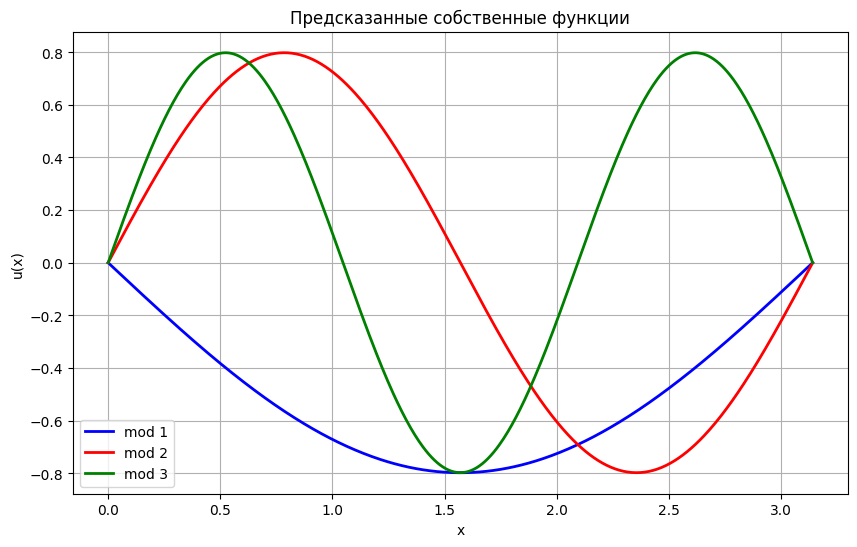

In [34]:
# Создаём плотную сетку для гладкого графика (опционально)
x_plot = torch.linspace(0, np.pi, 500, device=device).unsqueeze(1)

# Получаем предсказания
model.eval()
with torch.no_grad():
    u_pred = model(x_plot)  

# Переносим на CPU и в numpy
x_np = x_plot.cpu().numpy().flatten()
u_np = u_pred.cpu().numpy()  # (500, 3)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(x_np, u_np[:, 0], label='mod 1', color='blue', linewidth=2)
plt.plot(x_np, u_np[:, 1], label='mod 2', color='red', linewidth=2)
plt.plot(x_np, u_np[:, 2], label='mod 3', color='green', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Предсказанные собственные функции')
plt.legend()
plt.grid(True)
plt.show()